## 2. Arc Calibration

This notebook demonstrates how to extract a spectrum from the arc file and how to get a preliminary wavelength solution.

In [1]:
%matplotlib inline

Import all necessary packages and modules:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.io import fits
from scipy.signal import find_peaks
from rascal.calibrator import Calibrator
from rascal.util import refine_peaks
import pickle
import os

/nexus/posix0/MIA-astro-env/lkreidberg/staudtpat/.conda/envs/Tiberius/lib/python3.8/site-packages/rascal/calibrator.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Take care that the origin of the imshow plots of the matplotlib library is in the lower left corner

In [3]:
plt.rcParams['image.origin'] = 'lower'

Get the path to relevant directories:

In [4]:
parent_direc = os.path.dirname(os.getcwd()) + '/'
extraction_direc = os.path.dirname(os.path.dirname(os.path.dirname(parent_direc))) + '/'

Load all necessary files :
- The cleaned star fluxes from Notebook 1
- The trace of the spectra extractions

In [5]:
# Load in stellar spectra
s1 = pickle.load(open(parent_direc+'pickled_objects/star1_flux_cleaned.pickle','rb'))
s2 = pickle.load(open(parent_direc+'pickled_objects/star2_flux_cleaned.pickle','rb'))

# Load in x positions of traces, so that we can extract the arc spectra at the same locations as the stars
trace1 = pickle.load(open(extraction_direc+'pickled_objects/x_positions_1.pickle','rb'))
trace2 = pickle.load(open(extraction_direc+'pickled_objects/x_positions_2.pickle','rb'))


Load the arc frame you want to use :

In [6]:
arc_fits = fits.open('/nexus/posix0/MIA-astro-env/lkreidberg/staudtpat/WASP_69b/Tiberius_reduction/EFOSC2_280723/calib_files/EFOSC.2023-07-29T14_54_34.437.fits')


arc = arc_fits[0].data
header = arc_fits[0].header

arc = arc.astype(float)

# Get the conditions at which the measurements have been done
temperature = header["HIERARCH ESO TEL AMBI TEMP"] + 273.15
pressure = header["HIERARCH ESO TEL AMBI PRES START"] * 100
humidity = header["HIERARCH ESO TEL AMBI RHUM"]

Define the "row_min" and "row_max" paramter as you used for the extraction:

In [7]:
row_min = 50
row_max = 1010

rows = np.arange(row_min,row_max)

nrows = len(s1[0])
nframes = len(s1)

Define the minimum and maximum wavelength of the used grism.

Here Gr#11 with a range from 3380-7520 and a dispersion of 4.08 for an image with CCD#40 of 1030X1030 were used.

In [8]:
grism_min = 3380
grism_max = 7520

dispersion = 2 * 2.04
CCD_dim = 1030

Lets calculate now the wavelength min and wavelength max:

Example for grism #11


X = 3380 + 100 * 4.08 = 3788 A


Y = 7520 - 15 * 4.08 = 7458.8 A

In [9]:
min_wave = grism_min + row_min*dispersion
max_wave = grism_max - (CCD_dim-row_max)*dispersion

print(min_wave, max_wave)

3584.0 7438.4


Now calculate the sliced_arcs for trace 1 and trace 2

In [10]:
slice_arc_1 = []
slice_arc_2 = []

for i, r in enumerate(rows):
    row = arc[r]
    slice_arc_1.append(row[int(trace1[nframes//2][i])])
    slice_arc_2.append(row[int(trace2[nframes//2][i])])
 
slice_arc_1 = np.array(slice_arc_1)
slice_arc_2 = np.array(slice_arc_2)

Plot the arc image and the two traces in the same figure:

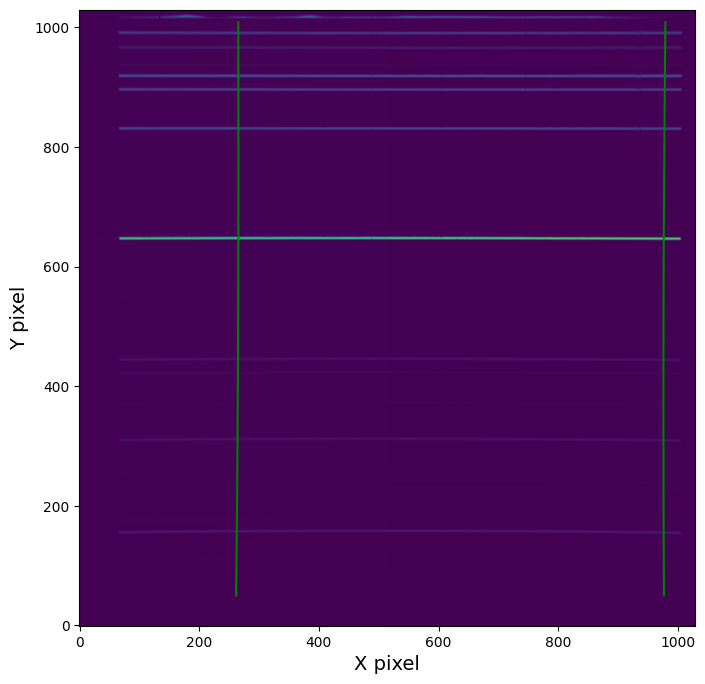

In [11]:
plt.figure(figsize=(8,8))
plt.imshow(arc)
plt.plot(trace1[nframes//2],rows,color='g')
plt.plot(trace2[nframes//2],rows,color='g')
plt.ylabel('Y pixel', size=14)
plt.xlabel('X pixel', size=14)
plt.show()

Now let us plot the sliced arcs of the two traces

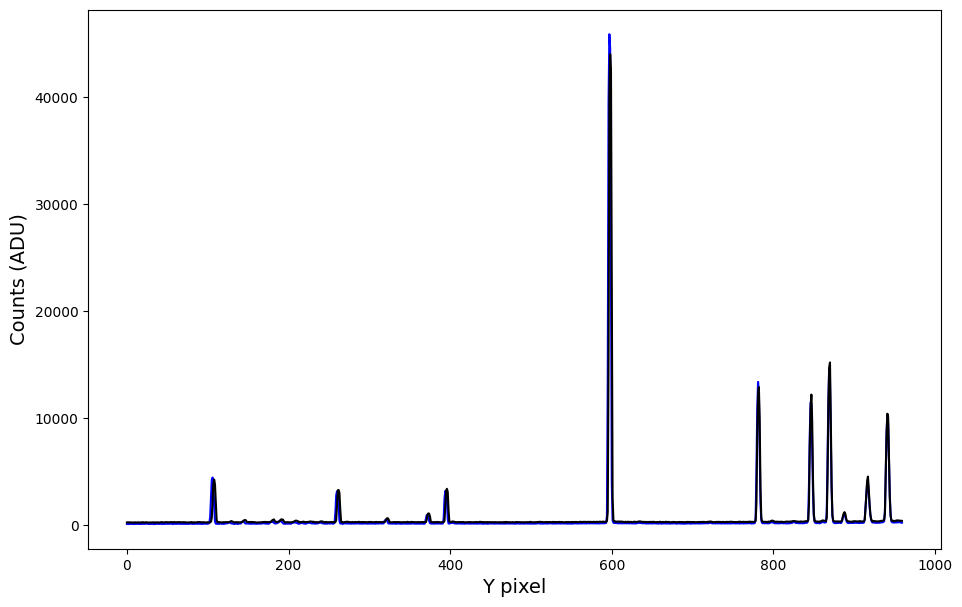

In [12]:
plt.figure(figsize=(11,7))
plt.plot(slice_arc_1,color='b')
plt.plot(slice_arc_2, color='k')
plt.xlabel('Y pixel', size=14)
plt.ylabel('Counts (ADU)', size=14)
plt.show()


Define the function "finding_peaks":
- to find the peaks int the arc file
- to plot the peaks for a comparison to get afterwards fixed wavelength/pixel pairs for fitting.

In [13]:
def finding_peaks(spectrum):
    
    peaks, _ = find_peaks(spectrum, prominence=150, distance=15, threshold=None)
    print("Peaks: ", peaks)
    
    peaks_refined=refine_peaks(spectrum, peaks, window_width=4)
    
    # Set up the Calibrator object
    c = Calibrator(peaks_refined, spectrum)

    c.set_calibrator_properties(num_pix=len(spectrum),
                                plotting_library='matplotlib',
                                log_level='info')

    c.plot_arc()

Define the function "rascal_find_wvl_solution":
- to find the wavelengths to the peaks out of the arc spectrum
- to fit the spectrum (which consists of the position of the trace) with the wavelength solution

You can change parameters as "max_tries" and "fit_deg" to get better results.

In [14]:
def rascal_find_wvl_solution(spectrum, wvl_min, wvl_max):
    global row_max, row_min, temperature, pressure, humidity, pix, wave
    peaks, _ = find_peaks(spectrum, prominence=150, distance=15, threshold=None)
    print("Peaks: ", peaks)
    
    peaks_refined=refine_peaks(spectrum, peaks, window_width=4)
    
    # Set up the Calibrator object
    c = Calibrator(peaks_refined, spectrum)

    c.set_calibrator_properties(num_pix=len(spectrum),
                                plotting_library='matplotlib',
                                log_level='info')

    #c.plot_arc()

    c.set_hough_properties(min_wavelength=wvl_min,
                           max_wavelength=wvl_max,
                           range_tolerance=500.,
                           linearity_tolerance=50)
    
    c.set_ransac_properties(sample_size=5,
                            top_n_candidate=8,
                            minimum_matches=8)

    c.add_atlas(elements=["He","Ar"], min_atlas_wavelength=wvl_min, max_atlas_wavelength=wvl_max,
                min_intensity=20, pressure=pressure, temperature=temperature, relative_humidity=humidity)

    #c.list_atlas() # to see all imported lines

    c.do_hough_transform()

    c.set_known_pairs(pix=pix, wave=wave)
    
    # Solve for the wavelength calibration
    best_polyfit_coefficient, matched_peaks, matched_atlas, rms, residual, peak_utilisation, atlas_utilisation = c.fit(
        max_tries=100000, fit_deg=4, progress=True)

    print("RMS: {}".format(rms))
    print("Stdev error: {} A".format(np.abs(residual).std()))
    print("Peaks utilisation rate: {}%".format(peak_utilisation*100))

    c.plot_fit(best_polyfit_coefficient)

    print("Best polyfit coefficient", best_polyfit_coefficient)
    best_polyfit_coefficient = np.array(best_polyfit_coefficient)
    
    #print(c.polyval(best_polyfit_coefficient,0))
    wvl = c.polyval(np.arange(0,row_max-row_min),best_polyfit_coefficient)
    return wvl

Now use the arc spectrum of trace 1 to find the positions in pixels of the emission lines:

[Tue, 26 Aug 2025 05:24:21] INFO [calibrator.py:930] num_pix is set to 960.
[Tue, 26 Aug 2025 05:24:21] INFO [calibrator.py:942] pixel_list is set to None.
[Tue, 26 Aug 2025 05:24:21] INFO [calibrator.py:971] Plotting with matplotlib.


Peaks:  [106 143 189 208 260 321 371 394 597 781 846 869 888 916 941]


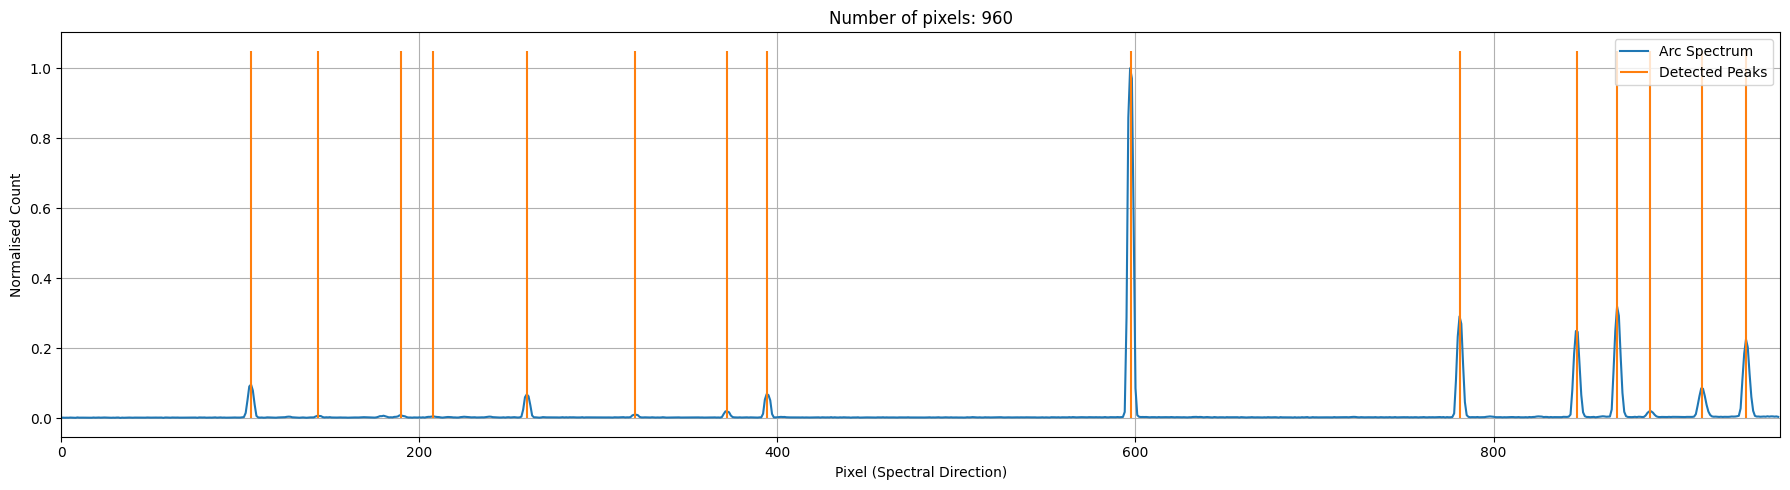

In [15]:
finding_peaks(slice_arc_1)

Now have a look to the documentation of EFOSC https://www.eso.org/sci/facilities/lasilla/instruments/efosc/doc/manual/EFOSC2manual_v4.1.pdf for the respective grism to set a few known lines.

In [16]:
pix = (106, 597, 941) 
wave = (3888.6, 5875.6, 7384.0)

Finally lets call the "rascal_find_wvl_solution" to find the wavelength solution of our spectra:

[Tue, 26 Aug 2025 05:25:29] INFO [calibrator.py:930] num_pix is set to 960.
[Tue, 26 Aug 2025 05:25:29] INFO [calibrator.py:942] pixel_list is set to None.
[Tue, 26 Aug 2025 05:25:29] INFO [calibrator.py:971] Plotting with matplotlib.
[Tue, 26 Aug 2025 05:25:29] WARNING [calibrator.py:1299] Using add_atlas is now deprecated. Please use the new Atlas class.


Peaks:  [106 143 189 208 260 321 371 394 597 781 846 869 888 916 941]


  0%|          | 0/100000 [00:00<?, ?it/s]

[Tue, 26 Aug 2025 05:27:02] INFO [calibrator.py:750] Found: 13
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:805] Peak at: 3888.9218548721014 A
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:809] - matched to 3888.9218548721014 A
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:805] Peak at: 4026.474081268224 A
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:809] - matched to 4026.474081268224 A
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:805] Peak at: 4198.610995319919 A
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:809] - matched to 4198.610995319919 A
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:805] Peak at: 4471.7919673648585 A
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:809] - matched to 4471.7919673648585 A
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:805] Peak at: 4713.473356574317 A
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:809] - matched to 4713.473356574317 A
[Tue, 26 Aug 2025 05:27:03] INFO [plotting.py:805] Peak at: 4922.272644672796 A
[Tue, 26 Aug 2025 05:27:03] INFO 

RMS: 0.4810675321941391
Stdev error: 0.3615553761800765 A
Peaks utilisation rate: 86.66666666666667%


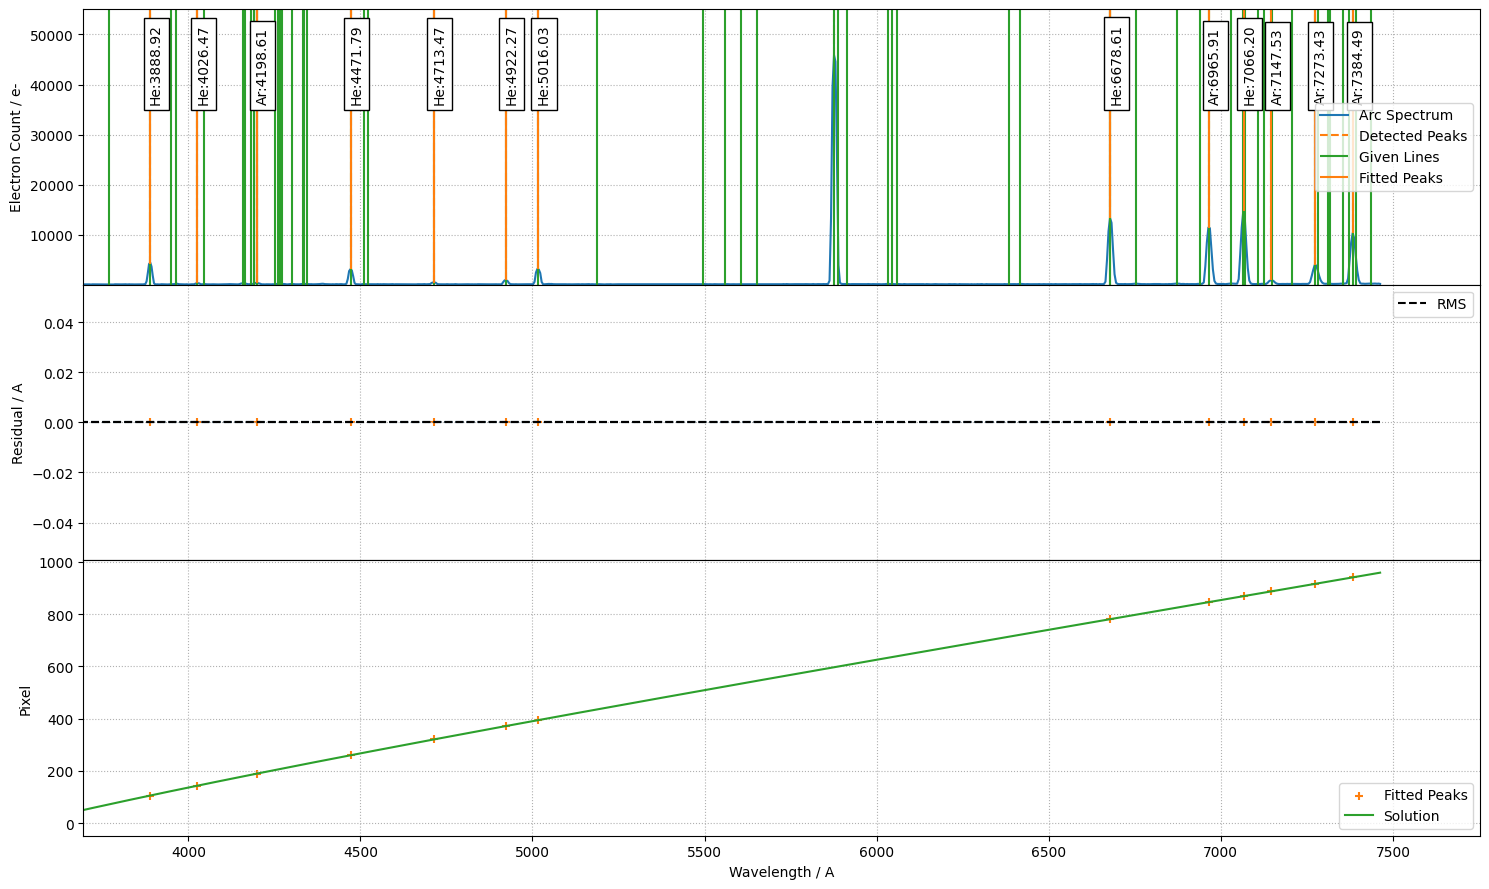

Best polyfit coefficient [ 3.52644673e+03  3.24928570e+00  1.78899339e-03 -1.29427900e-06
  3.74148172e-10]


In [17]:
wvl1 = rascal_find_wvl_solution(slice_arc_1, min_wave, max_wave)

Now we repeat the same for the second trace:

[Tue, 26 Aug 2025 05:27:54] INFO [calibrator.py:930] num_pix is set to 960.
[Tue, 26 Aug 2025 05:27:54] INFO [calibrator.py:942] pixel_list is set to None.
[Tue, 26 Aug 2025 05:27:54] INFO [calibrator.py:971] Plotting with matplotlib.


Peaks:  [108 146 191 209 262 323 373 396 598 782 847 870 888 917 941]


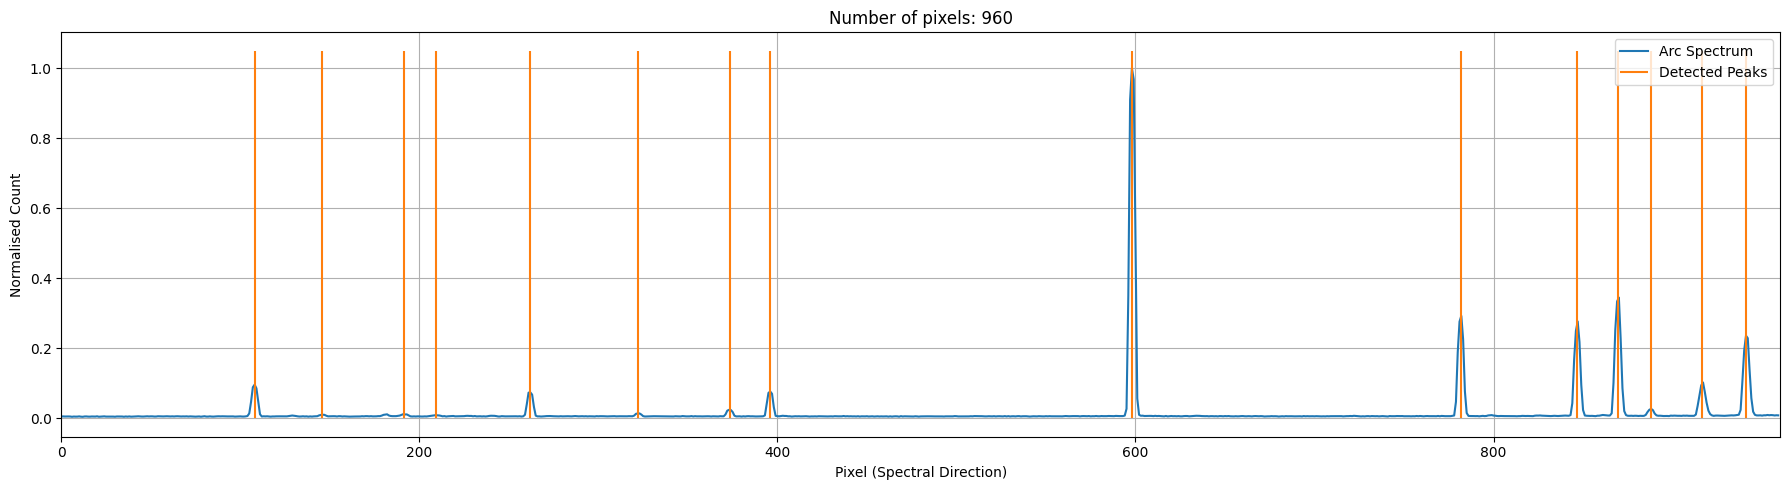

In [18]:
finding_peaks(slice_arc_2)

Again define the peaks you want to set fix:

In [19]:
pix = (108, 598, 941) 
wave = (3888.6, 5875.6, 7384.0)

Finally lets call the "rascal_find_wvl_solution" a last time to find the wavelength solution of our spectra:

[Tue, 26 Aug 2025 05:28:19] INFO [calibrator.py:930] num_pix is set to 960.
[Tue, 26 Aug 2025 05:28:19] INFO [calibrator.py:942] pixel_list is set to None.
[Tue, 26 Aug 2025 05:28:19] INFO [calibrator.py:971] Plotting with matplotlib.
[Tue, 26 Aug 2025 05:28:19] WARNING [calibrator.py:1299] Using add_atlas is now deprecated. Please use the new Atlas class.


Peaks:  [108 146 191 209 262 323 373 396 598 782 847 870 888 917 941]


  0%|          | 0/100000 [00:00<?, ?it/s]

[Tue, 26 Aug 2025 05:29:58] INFO [calibrator.py:750] Found: 11
[Tue, 26 Aug 2025 05:29:58] INFO [plotting.py:805] Peak at: 4200.9685303131355 A
[Tue, 26 Aug 2025 05:29:58] INFO [plotting.py:809] - matched to 4200.9685303131355 A
[Tue, 26 Aug 2025 05:29:59] INFO [plotting.py:805] Peak at: 4266.584578774224 A
[Tue, 26 Aug 2025 05:29:59] INFO [plotting.py:809] - matched to 4266.584578774224 A
[Tue, 26 Aug 2025 05:29:59] INFO [plotting.py:805] Peak at: 4471.7919673648585 A
[Tue, 26 Aug 2025 05:29:59] INFO [plotting.py:809] - matched to 4471.7919673648585 A
[Tue, 26 Aug 2025 05:29:59] INFO [plotting.py:805] Peak at: 4713.473356574317 A
[Tue, 26 Aug 2025 05:29:59] INFO [plotting.py:809] - matched to 4713.473356574317 A
[Tue, 26 Aug 2025 05:29:59] INFO [plotting.py:805] Peak at: 4922.272644672796 A
[Tue, 26 Aug 2025 05:29:59] INFO [plotting.py:809] - matched to 4922.272644672796 A
[Tue, 26 Aug 2025 05:29:59] INFO [plotting.py:805] Peak at: 5016.025825313089 A
[Tue, 26 Aug 2025 05:29:59] INFO 

RMS: 0.43293510374045846
Stdev error: 0.320355734072455 A
Peaks utilisation rate: 73.33333333333333%


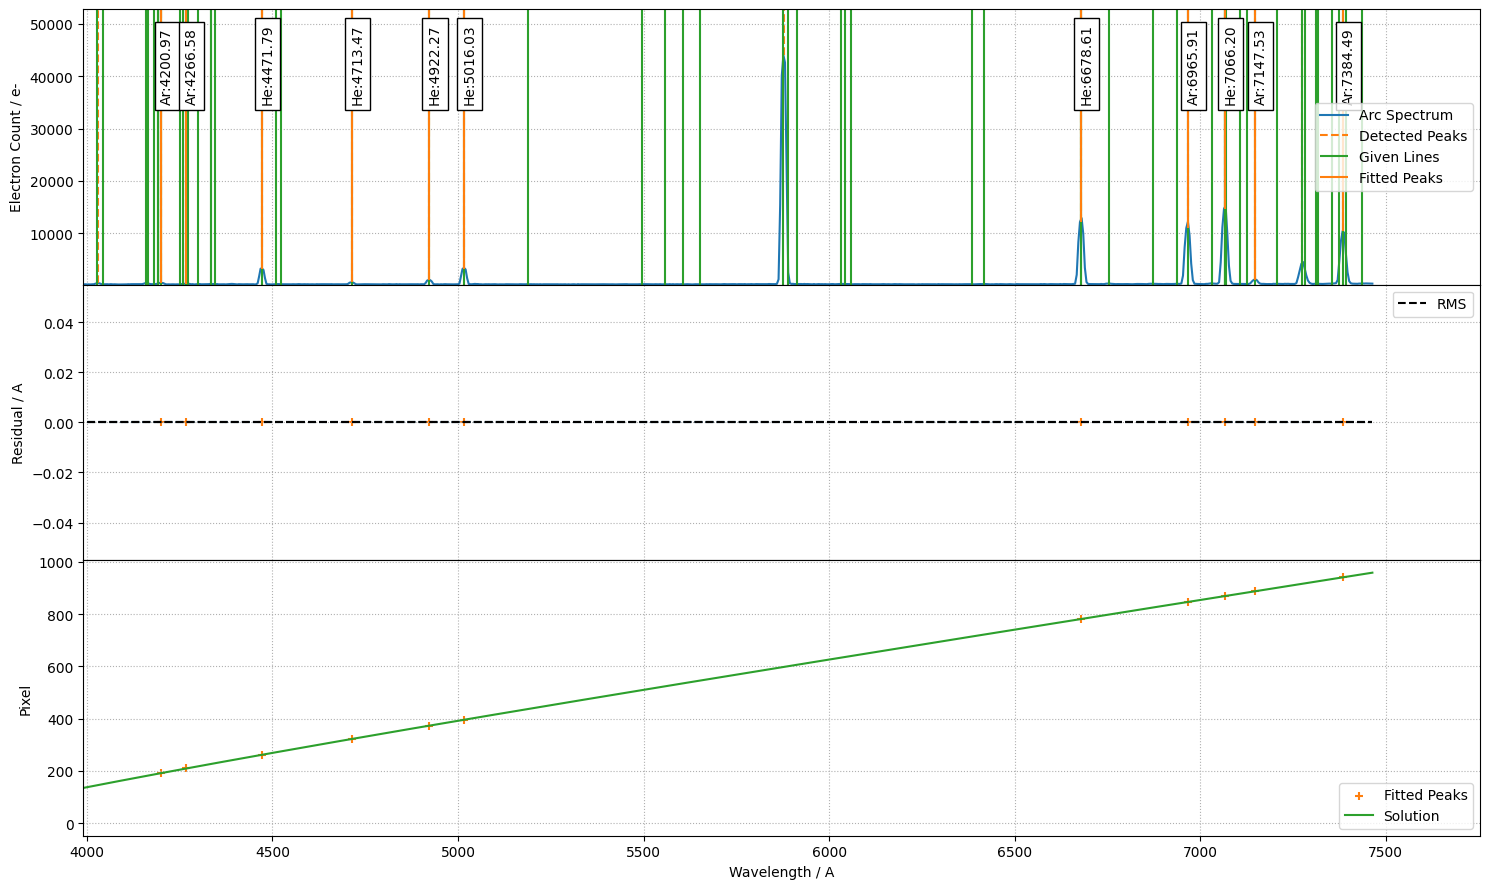

Best polyfit coefficient [ 3.53213179e+03  3.13342235e+00  2.14630596e-03 -1.71752582e-06
  5.52970242e-10]


In [20]:
wvl2 = rascal_find_wvl_solution(slice_arc_2, min_wave, max_wave)

Check the wavelength solutions first entries for our two fits:

In [21]:
print('First entry of wavelength solution for trace 1: ', wvl1[0])
print('First entry of wavelength solution for trace 2: ', wvl2[0])
print('Difference between both solutions: ', np.abs(wvl2[0]-wvl1[0]))

First entry of wavelength solution for trace 1:  3526.446731702892
First entry of wavelength solution for trace 2:  3532.131789419572
Difference between both solutions:  5.685057716680149


In [22]:
print('Last entry of wavelength solution for trace 1: ', wvl1[-1])
print('Last entry of wavelength solution for trace 2: ', wvl2[-1])
print('Difference between both solutions: ', np.abs(wvl2[-1]-wvl1[-1]))

Last entry of wavelength solution for trace 1:  7462.753855673707
Last entry of wavelength solution for trace 2:  7463.896871261562
Difference between both solutions:  1.1430155878551886


Both solutions match well with each other.

Finally let us write the arc solutions to pickle files.

In [23]:
pickle.dump(wvl1,open(parent_direc+'/pickled_objects/arc_solution_trace1_rascal.pickle','wb'))
pickle.dump(wvl2,open(parent_direc+'/pickled_objects/arc_solution_trace2_rascal.pickle','wb'))